<small>

#### Symbols

*  $B$                                             : batch size           
*  $d$                                             : embedding dimension  
*  $n_{\text{users}}$                              : total users          
*  $n_{\text{items}}$                              : total items          
*  $U \in \mathbb{R}^{\,n_{\text{users}}\times d}$ : user-embedding table 
*  $V \in \mathbb{R}^{\,n_{\text{items}}\times d}$ : item-embedding table 

#### Math
Let $E$ denote a batch-sized stack of user-embedding vectors. $U \in \mathbb{R}^{n_{users} \times d }$ is the full table of learned user embeddings.


$\text{logits} = E\,V^{\!\top} \in \mathbb{R}^{B \times n_{\text{items}}}$

Score of a user $u_b$ when linked to an item $v_i$: $s_{b,i} = \langle \mathbf{u}_b,\; \mathbf{v}_i \rangle$




#### Binary Cross Entropy

$\ell_{b,i} \;=\;-\Bigl[\,y_{b,i}\,\log\sigma(s_{b,i})\;+\;\bigl(1-y_{b,i}\bigr)\,\log\!\bigl(1-\sigma(s_{b,i})\bigr)\Bigr],\qquad\sigma(x) \;=\; \frac{1}{1+e^{-x}}$


$\mathcal{L} \;=\;\frac{1}{B}\;\sum_{b=1}^{B}\sum_{i=1}^{n_{\text{items}}}\ell_{b,i}$


</small>

In [3]:

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

# Data
n_users = 8
n_items = 8

pairs = np.array([[i, i] for i in range(n_users)] * 25)

user_ids = pairs[:, 0].astype("int32")  
item_ids = pairs[:, 1].astype("int32")

batch_size = 16                                         # B is the batch size
epochs      = 200  
latent_dim  = 16

# 2 · Model
class NoSoftmax(tf.keras.Model): # W.V
    def __init__(self, n_users, n_items, d):
        super().__init__()
        self.user_emb = tf.keras.layers.Embedding(n_users, d)
        self.item_emb = tf.keras.layers.Embedding(n_items, d)
        self.item_emb.build((None,))               

    def call(self, users):
        u_vec = self.user_emb(users)        
        item_matrix = tf.transpose(self.item_emb.embeddings)  
        logits = tf.linalg.matmul(u_vec, item_matrix)   
        return logits

model = NoSoftmax(n_users, n_items, latent_dim)

# Custom loss
def custom_loss(y_true, logits):

    y_true = tf.cast(y_true, tf.int32)
    labels = tf.one_hot(y_true, depth=n_items)              
    loss = tf.nn.sigmoid_cross_entropy_with_logits(
        labels=labels, logits=logits
    )                                                    
    return tf.reduce_mean(tf.reduce_sum(loss, axis=1))

# Train
train_ds = (
    tf.data.Dataset.from_tensor_slices((user_ids, item_ids))
    .shuffle(buffer_size=len(user_ids))
    .batch(batch_size)
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(2e-2),
    loss=custom_loss,
    run_eagerly=True
)
model.fit(train_ds, epochs=epochs, verbose=0)

# Inference
def predict_distribution(model, user_id: int):
    logits = model(tf.constant([user_id], dtype=tf.int32)) 
    probs  = tf.math.sigmoid(logits)
    probs  = probs / tf.reduce_sum(probs, axis=1, keepdims=True)
    return probs.numpy().squeeze()



User 0 probabilities: [1.00e+00 1.01e-05 8.83e-06 9.57e-06 6.59e-06 1.61e-09 8.49e-06 1.05e-05]
User 1 probabilities: [9.77e-06 1.00e+00 7.37e-06 8.31e-06 7.88e-06 7.65e-06 6.85e-06 4.77e-06]
User 2 probabilities: [8.40e-06 5.49e-06 1.00e+00 8.83e-06 7.43e-06 7.91e-06 3.60e-08 8.88e-06]
User 3 probabilities: [8.65e-06 7.22e-06 9.41e-06 1.00e+00 1.40e-05 7.26e-06 8.95e-06 4.87e-09]
User 4 probabilities: [9.58e-06 7.78e-06 9.19e-06 1.05e-05 1.00e+00 7.78e-06 4.80e-06 6.65e-06]
User 5 probabilities: [1.24e-08 7.62e-06 8.97e-06 7.80e-06 8.31e-06 1.00e+00 1.08e-05 8.36e-06]
User 6 probabilities: [6.11e-06 6.15e-06 2.72e-08 9.15e-06 5.36e-06 1.28e-05 1.00e+00 9.60e-06]
User 7 probabilities: [1.01e-05 7.63e-06 9.70e-06 2.82e-09 3.65e-06 8.56e-06 9.87e-06 1.00e+00]


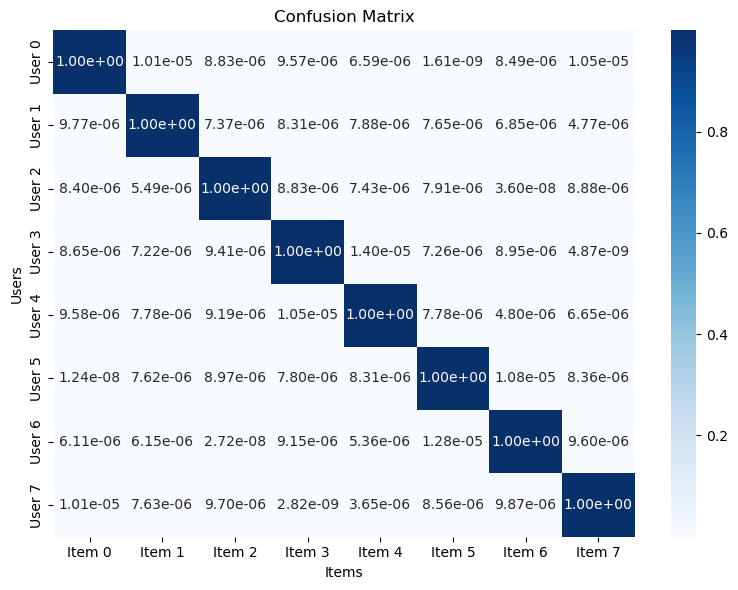

In [4]:
confusion_matrix = np.zeros((n_users, n_items))


# To display probabilities in scientific notation with only 2 digits after the decimal
np.set_printoptions(precision=2,          # two digits
                    suppress=False,       # keep scientific notation
                    formatter={'float': '{:0.2e}'.format})

for u in range(n_users):
    probs = predict_distribution(model, u)
    print(f"User {u} probabilities: {probs}")  
    confusion_matrix[u] = probs


plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt=".2e", cmap="Blues", xticklabels=[f"Item {i}" for i in range(n_items)], yticklabels=[f"User {i}" for i in range(n_users)])
plt.title("Confusion Matrix")
plt.xlabel("Items")
plt.ylabel("Users")
plt.tight_layout()
plt.show()
